# 🩸 HorRAGor – Démonstration du Pipeline d'Ingestion

**Partie 1 – Ingestion multi-sources de données horrifiques**

Ce notebook démontre chaque étape du pipeline :
1. Configuration et imports
2. Extraction depuis les 5 sources (mock/échantillon)
3. Normalisation des données
4. Déduplication
5. Fusion MDM (Master Data Management)
6. Filtrage et export Gold
7. Statistiques du jeu de données final
8. Diagrammes Merise

> **Note :** Ce notebook tourne sans credentials Supabase ni API TMDB grâce aux données mock intégrées.

## 0. Dépendances

In [13]:
# Vérification des imports principaux
import sys, importlib

REQUIRED = ['polars', 'rapidfuzz', 'bs4', 'dateutil', 'sqlalchemy',
            'pydantic_settings', 'tenacity', 'loguru', 'pyarrow', 'pandas']

missing = []
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
        print(f'  ✅ {pkg}')
    except ImportError:
        missing.append(pkg)
        print(f'  ❌ {pkg} — MANQUANT')

if missing:
    print(f'\n⚠️  Installez : pip install {" ".join(missing)}')
else:
    print('\n✅ Toutes les dépendances sont présentes !')

  ✅ polars
  ✅ rapidfuzz
  ✅ bs4
  ✅ dateutil
  ✅ sqlalchemy
  ✅ pydantic_settings
  ✅ tenacity
  ✅ loguru
  ✅ pyarrow
  ✅ pandas

✅ Toutes les dépendances sont présentes !


## 1. Configuration

In [14]:
import os
from pathlib import Path

# On pointe vers le projet
PROJECT_ROOT = Path().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f'Racine du projet : {PROJECT_ROOT}')

# Import de la configuration (sans .env requis)
from src.config import settings
print(f'Seuil fuzzy      : {settings.fuzzy_threshold}')
print(f'Seuil votes IMDB : {settings.imdb_min_votes}')
print(f'Headless Chrome  : {settings.selenium_headless}')

Racine du projet : C:\Users\flavi\OneDrive\Documents\Simplon\Exercices Simplon France\HorRAGor
Seuil fuzzy      : 85
Seuil votes IMDB : 1000
Headless Chrome  : True


## 2. Données de démonstration (Mock)

Simulation de ce que chaque extracteur retournerait.

In [15]:
# ─── Données mock représentant les 5 sources ───────────────────────────────

MOCK_TMDB = [
    {'tmdb_id': 694, 'title': 'The Shining', 'original_title': 'The Shining',
     'release_date': '1980-05-23', 'genres': ['Horror', 'Drama'],
     'overview': 'A family heads to an isolated hotel for the winter.',
     'score_critique': 8.4, 'vote_count': 22000, 'source': 'tmdb'},
    {'tmdb_id': 539, 'title': 'Psycho', 'original_title': 'Psycho',
     'release_date': '1960-09-08', 'genres': ['Horror', 'Mystery'],
     'overview': 'A secretary encounters a mysterious motel owner.',
     'score_critique': 8.5, 'vote_count': 14000, 'source': 'tmdb'},
    {'tmdb_id': 1091, 'title': 'The Thing', 'original_title': 'The Thing',
     'release_date': '1982-06-25', 'genres': ['Horror', 'Science Fiction'],
     'overview': 'A research team in Antarctica is hunted by a shape-shifting alien.',
     'score_critique': 8.2, 'vote_count': 18000, 'source': 'tmdb'},
]

MOCK_RT = [
    {'title': 'The Shining', 'release_date': '1980',
     'tomatometer': 84, 'audience_score': 94,
     'consensus': 'Dread-filled and visually arresting.',
     'url_rt': 'https://www.rottentomatoes.com/m/shining', 'source': 'rotten_tomatoes'},
    {'title': 'Psycho', 'release_date': '1960',
     'tomatometer': 97, 'audience_score': 95,
     'consensus': 'A masterpiece of psychological terror.',
     'url_rt': 'https://www.rottentomatoes.com/m/psycho', 'source': 'rotten_tomatoes'},
]

MOCK_KAGGLE = [
    {'title': 'It', 'release_date': '2017-09-08', 'genres': 'Horror|Thriller',
     'imdb_id': 'tt1396484', 'score_critique': 7.3,
     'vote_count': 32000, 'source': 'kaggle'},
    {'title': 'Get Out', 'release_date': '2017-02-24', 'genres': 'Horror|Mystery',
     'imdb_id': 'tt5052448', 'score_critique': 7.8,
     'vote_count': 28000, 'source': 'kaggle'},
    # Doublon intentionnel de The Shining pour tester la dédup
    {'title': 'The Shining', 'release_date': '1980-05-23', 'genres': 'Horror|Drama',
     'imdb_id': 'tt0081505', 'score_critique': 8.4,
     'vote_count': 22000, 'source': 'kaggle'},
]

MOCK_IMDB = [
    {'title': 'The Shining', 'original_title': 'The Shining',
     'release_date': '1980', 'imdb_id': 'tt0081505',
     'score_critique': 8.4, 'vote_count': 950000, 'source': 'imdb'},
    {'title': 'Hereditary', 'original_title': 'Hereditary',
     'release_date': '2018', 'imdb_id': 'tt7784604',
     'score_critique': 7.3, 'vote_count': 310000, 'source': 'imdb'},
]

MOCK_SPARK = [
    {'title': 'A Quiet Place', 'release_date': '2018-04-06',
     'genre': 'Horror', 'score_critique': 7.5,
     'vote_count': 380000, 'source': 'spark'},
    {'title': 'The Conjuring', 'release_date': '2013-07-19',
     'genre': 'Horror', 'score_critique': 7.5,
     'vote_count': 430000, 'source': 'spark'},
]

all_raw = MOCK_TMDB + MOCK_KAGGLE + MOCK_IMDB + MOCK_SPARK + MOCK_RT
print(f'Total enregistrements bruts : {len(all_raw)}')
print(f'  - TMDB          : {len(MOCK_TMDB)}')
print(f'  - Rotten Tomato : {len(MOCK_RT)}')
print(f'  - Kaggle        : {len(MOCK_KAGGLE)}')
print(f'  - IMDB          : {len(MOCK_IMDB)}')
print(f'  - Spark         : {len(MOCK_SPARK)}')

Total enregistrements bruts : 12
  - TMDB          : 3
  - Rotten Tomato : 2
  - Kaggle        : 3
  - IMDB          : 2
  - Spark         : 2


## 3. Normalisation

In [16]:
from src.transformers.normalizer import (
    normalize_date, normalize_score_tmdb, normalize_score_rt_tomatometer,
    normalize_text, normalize_record
)

# ─── Démonstration de chaque fonction ─────────────────────────────────────
print('=== normalize_date() ===')
tests_date = ['1980-05-23', '1980', 1982, '\\N', None, '']
for d in tests_date:
    print(f'  {repr(d):20s} → {normalize_date(d)}')

print('\n=== normalize_score_tmdb() (0-10 → 0-100) ===')
for s in [8.4, 10, 0, None, 11]:
    print(f'  {s} → {normalize_score_tmdb(s)}')

print('\n=== normalize_score_rt() (0-100 natif) ===')
for s in [84, 100, 0, None, 101]:
    print(f'  {s} → {normalize_score_rt_tomatometer(s)}')

print('\n=== normalize_text() ===')
for t in ['  Hello  world  ', '<p>Bold <b>text</b></p>', '', None]:
    print(f'  {repr(t):30s} → {normalize_text(t)}')

=== normalize_date() ===
  '1980-05-23'         → 1980-05-23
  '1980'               → 1980-01-01
  1982                 → 1982-01-01
  '\\N'                → None
  None                 → None
  ''                   → None

=== normalize_score_tmdb() (0-10 → 0-100) ===
  8.4 → 8.4
  10 → 10.0
  0 → 0.0
  None → None
  11 → None

=== normalize_score_rt() (0-100 natif) ===
  84 → 84.0
  100 → 100.0
  0 → 0.0
  None → None
  101 → None

=== normalize_text() ===
  '  Hello  world  '             → Hello world
  '<p>Bold <b>text</b></p>'      → Bold text
  ''                             → None
  None                           → None


In [17]:
import pandas as pd

# Normalisation de tous les enregistrements
normalized = [normalize_record(r) for r in all_raw]

df_norm = pd.DataFrame(normalized)
print(f'Colonnes disponibles après normalisation : {list(df_norm.columns)}')
display(df_norm[['title', 'release_date', 'score_critique', 'source', '_normalized_title']].head(15))

Colonnes disponibles après normalisation : ['tmdb_id', 'title', 'original_title', 'release_date', 'genres', 'overview', 'score_critique', 'vote_count', 'source', 'vote_average', 'tomatometer_score', 'audience_score', 'critics_consensus', '_normalized_title', 'imdb_id', 'genre', 'tomatometer', 'consensus', 'url_rt']


,title,release_date,score_critique,source,_normalized_title
0,The Shining,1980-05-23,8.4,tmdb,the shining
1,Psycho,1960-09-08,8.5,tmdb,psycho
2,The Thing,1982-06-25,8.2,tmdb,the thing
3,It,2017-09-08,7.3,kaggle,it
4,Get Out,2017-02-24,7.8,kaggle,get out
5,The Shining,1980-05-23,8.4,kaggle,the shining
6,The Shining,1980-01-01,8.4,imdb,the shining
7,Hereditary,2018-01-01,7.3,imdb,hereditary
8,A Quiet Place,2018-04-06,7.5,spark,a quiet place
9,The Conjuring,2013-07-19,7.5,spark,the conjuring


## 4. Déduplication

In [18]:
from src.transformers.deduplicator import deduplicate

deduped = deduplicate(normalized)

print(f'Avant dédup : {len(normalized)} enregistrements')
print(f'Après dédup : {len(deduped)} enregistrements')
print(f'Doublons éliminés : {len(normalized) - len(deduped)}')

df_dedup = pd.DataFrame(deduped)
display(df_dedup[['title', 'release_date', 'source']].sort_values('title'))

Avant dédup : 12 enregistrements
Après dédup : 9 enregistrements
Doublons éliminés : 3


,title,release_date,source
7,A Quiet Place,2018-04-06,spark
4,Get Out,2017-02-24,kaggle
6,Hereditary,2018-01-01,imdb
3,It,2017-09-08,kaggle
1,Psycho,1960-09-08,tmdb
8,The Conjuring,2013-07-19,spark
0,The Shining,1980-05-23,tmdb
5,The Shining,1980-05-23,kaggle
2,The Thing,1982-06-25,tmdb


## 5. Fusion MDM (Master Data Management)

Le `MDMMerger` consolide les enregistrements provenant de sources multiples :
- Priorité : `tmdb > imdb > kaggle > spark > rotten_tomatoes`
- Matching : `tmdb_id` exact → `imdb_id` exact → fuzzy sur titre+année (≥85)

In [19]:
from src.transformers.merger import MDMMerger

merger = MDMMerger(fuzzy_threshold=settings.fuzzy_threshold)
merged = merger.merge(deduped)

print(f'Après fusion MDM : {len(merged)} films maîtres')

df_merged = pd.DataFrame(merged)

# Colonnes intéressantes
cols_show = [c for c in ['title', 'release_date', 'source', 'tmdb_id', 'imdb_id',
                          'score_critique', 'tomatometer', 'overview'] if c in df_merged.columns]
display(df_merged[cols_show].sort_values('title'))

2026-04-23 16:05:20.362 | INFO     | src.transformers.merger:merge:83 - MDM : fusion de 9 enregistrements toutes sources
2026-04-23 16:05:20.363 | DEBUG    | src.transformers.merger:_fuzzy_match:174 - Fuzzy match trouvé : 'The Shining' (1980) ↔ 'The Shining' (1980) [score=100.0]
2026-04-23 16:05:20.364 | DEBUG    | src.transformers.merger:_apply_overview_fallback:254 - Pas de synopsis pour 'It' (sources: ['kaggle'])
2026-04-23 16:05:20.365 | DEBUG    | src.transformers.merger:_apply_overview_fallback:254 - Pas de synopsis pour 'Get Out' (sources: ['kaggle'])
2026-04-23 16:05:20.365 | DEBUG    | src.transformers.merger:_apply_overview_fallback:254 - Pas de synopsis pour 'Hereditary' (sources: ['imdb'])
2026-04-23 16:05:20.366 | DEBUG    | src.transformers.merger:_apply_overview_fallback:254 - Pas de synopsis pour 'A Quiet Place' (sources: ['spark'])
2026-04-23 16:05:20.367 | DEBUG    | src.transformers.merger:_apply_overview_fallback:254 - Pas de synopsis pour 'The Conjuring' (sources: 

Après fusion MDM : 8 films maîtres


,title,release_date,source,tmdb_id,imdb_id,score_critique,overview
6,A Quiet Place,2018-04-06,spark,NaN,NaN,7.5,NaN
4,Get Out,2017-02-24,kaggle,NaN,tt5052448,7.8,NaN
5,Hereditary,2018-01-01,imdb,NaN,tt7784604,7.3,NaN
3,It,2017-09-08,kaggle,NaN,tt1396484,7.3,NaN
1,Psycho,1960-09-08,tmdb,539.0,NaN,8.5,A secretary encounters a mysterious motel owner.
7,The Conjuring,2013-07-19,spark,NaN,NaN,7.5,NaN
0,The Shining,1980-05-23,tmdb,694.0,tt0081505,8.4,A family heads to an isolated hotel for the wi...
2,The Thing,1982-06-25,tmdb,1091.0,NaN,8.2,A research team in Antarctica is hunted by a s...


In [20]:
# Démonstration de l'enrichissement cross-source
print('Exemple d\'enrichissement pour "The Shining" :')
shining = next((r for r in merged if 'shining' in r.get('title','').lower()), None)
if shining:
    for k, v in shining.items():
        if not k.startswith('_') and v is not None:
            print(f'  {k:20s} : {str(v)[:60]}')

Exemple d'enrichissement pour "The Shining" :
  tmdb_id              : 694
  title                : The Shining
  original_title       : The Shining
  release_date         : 1980-05-23
  genres               : ['Horror', 'Drama']
  overview             : A family heads to an isolated hotel for the winter.
  score_critique       : 8.4
  vote_count           : 22000
  source               : tmdb
  imdb_id              : tt0081505


## 6. Filtrage Horror et Export Parquet

In [24]:
from src.pipeline import filter_horror_only

gold = filter_horror_only(merged)
print(f'Films conservés (horror) : {len(gold)} / {len(merged)}')

# Export Parquet
import pyarrow as pa
import pyarrow.parquet as pq

out_dir = PROJECT_ROOT / 'data' / 'gold'
out_dir.mkdir(parents=True, exist_ok=True)

# Sérialisation : convertir les listes en JSON strings
import json
gold_serializable = []
for r in gold:
    row = {k: (json.dumps(v) if isinstance(v, list) else v)
        for k, v in r.items() if not k.startswith('_')}
    gold_serializable.append(row)

df_gold = pd.DataFrame(gold_serializable)
pq_path = out_dir / 'demo_gold.parquet'
df_gold.to_parquet(pq_path, index=False)
print(f'Export Parquet : {pq_path} ({pq_path.stat().st_size} octets)')

2026-04-23 16:10:10.285 | INFO     | src.pipeline:filter_horror_only:178 - Filtrage horreur : 0 films hors-sujet exclus, 8 conservés


Films conservés (horror) : 8 / 8
Export Parquet : C:\Users\flavi\OneDrive\Documents\Simplon\Exercices Simplon France\HorRAGor\data\gold\demo_gold.parquet (9459 octets)


## 7. Statistiques du jeu de données Gold

Aperçu du jeu Gold :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tmdb_id,3.0,NaN,NaN,NaN,774.666667,284.70394,539.0,616.5,694.0,892.5,1091.0
title,8,8,The Shining,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_title,4,4,The Shining,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,8,8,1980-05-23,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,5,5,"[""Horror"", ""Drama""]",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,3,3,A family heads to an isolated hotel for the wi...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_critique,8.0,NaN,NaN,NaN,7.8125,0.491172,7.3,7.45,7.65,8.25,8.5
vote_count,8.0,NaN,NaN,NaN,154250.0,184339.554704,14000.0,21000.0,30000.0,327500.0,430000.0
source,8,4,tmdb,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vote_average,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


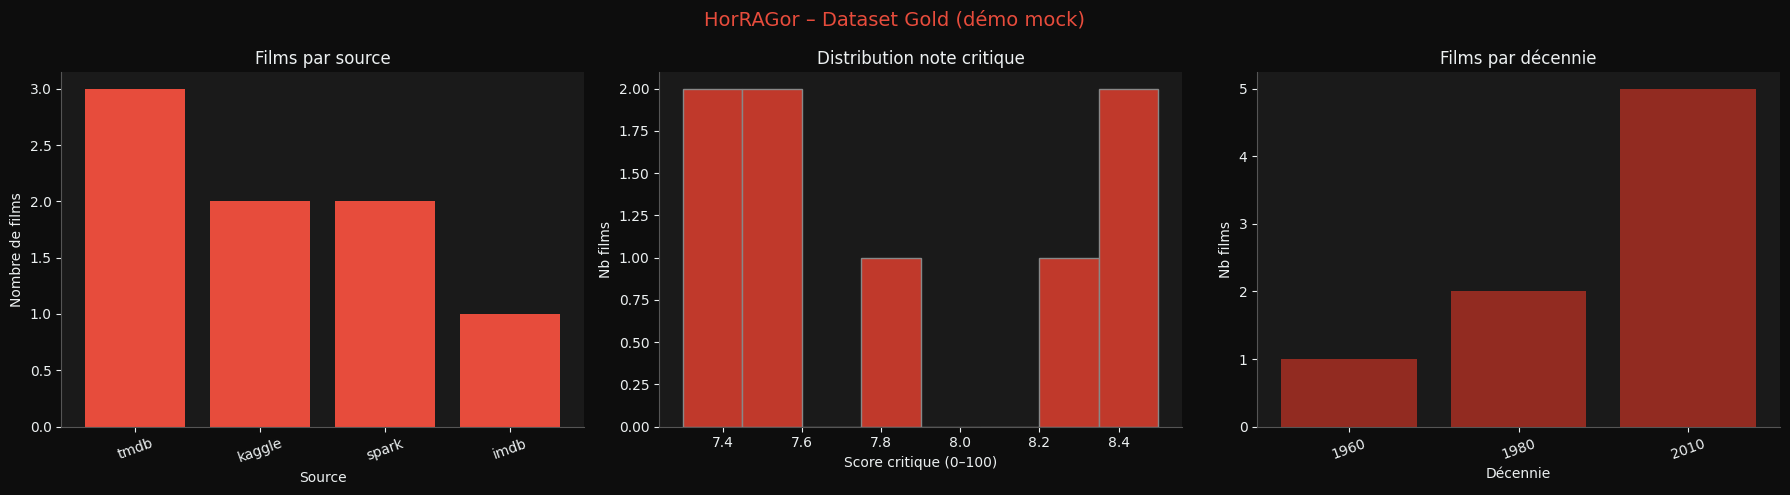

In [25]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.style as mstyle

plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#1a1a1a',
    'text.color':       '#ecf0f1',
    'axes.labelcolor':  '#ecf0f1',
    'xtick.color':      '#ecf0f1',
    'ytick.color':      '#ecf0f1',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.edgecolor':   '#555',
})

df_gold = pd.read_parquet(pq_path)
print('Aperçu du jeu Gold :')
display(df_gold.describe(include='all').T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d0d0d')
fig.suptitle('HorRAGor – Dataset Gold (démo mock)', color='#e74c3c', fontsize=14)

# Distribution par source
src_counts = df_gold['source'].value_counts()
axes[0].bar(src_counts.index, src_counts.values, color='#e74c3c')
axes[0].set_title('Films par source', color='#ecf0f1')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Nombre de films')
axes[0].tick_params(axis='x', rotation=20)

# Distribution note critique
scores = df_gold['score_critique'].dropna()
axes[1].hist(scores, bins=8, color='#c0392b', edgecolor='#888')
axes[1].set_title('Distribution note critique', color='#ecf0f1')
axes[1].set_xlabel('Score critique (0–100)')
axes[1].set_ylabel('Nb films')

# Distribution par décennie
df_gold['annee'] = pd.to_datetime(df_gold['release_date'], errors='coerce').dt.year
df_gold['decennie'] = (df_gold['annee'] // 10 * 10).astype('Int64')
dec_counts = df_gold['decennie'].value_counts().sort_index()
axes[2].bar([str(d) for d in dec_counts.index], dec_counts.values, color='#922b21')
axes[2].set_title('Films par décennie', color='#ecf0f1')
axes[2].set_xlabel('Décennie')
axes[2].set_ylabel('Nb films')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 8. Diagrammes Merise

### MCD

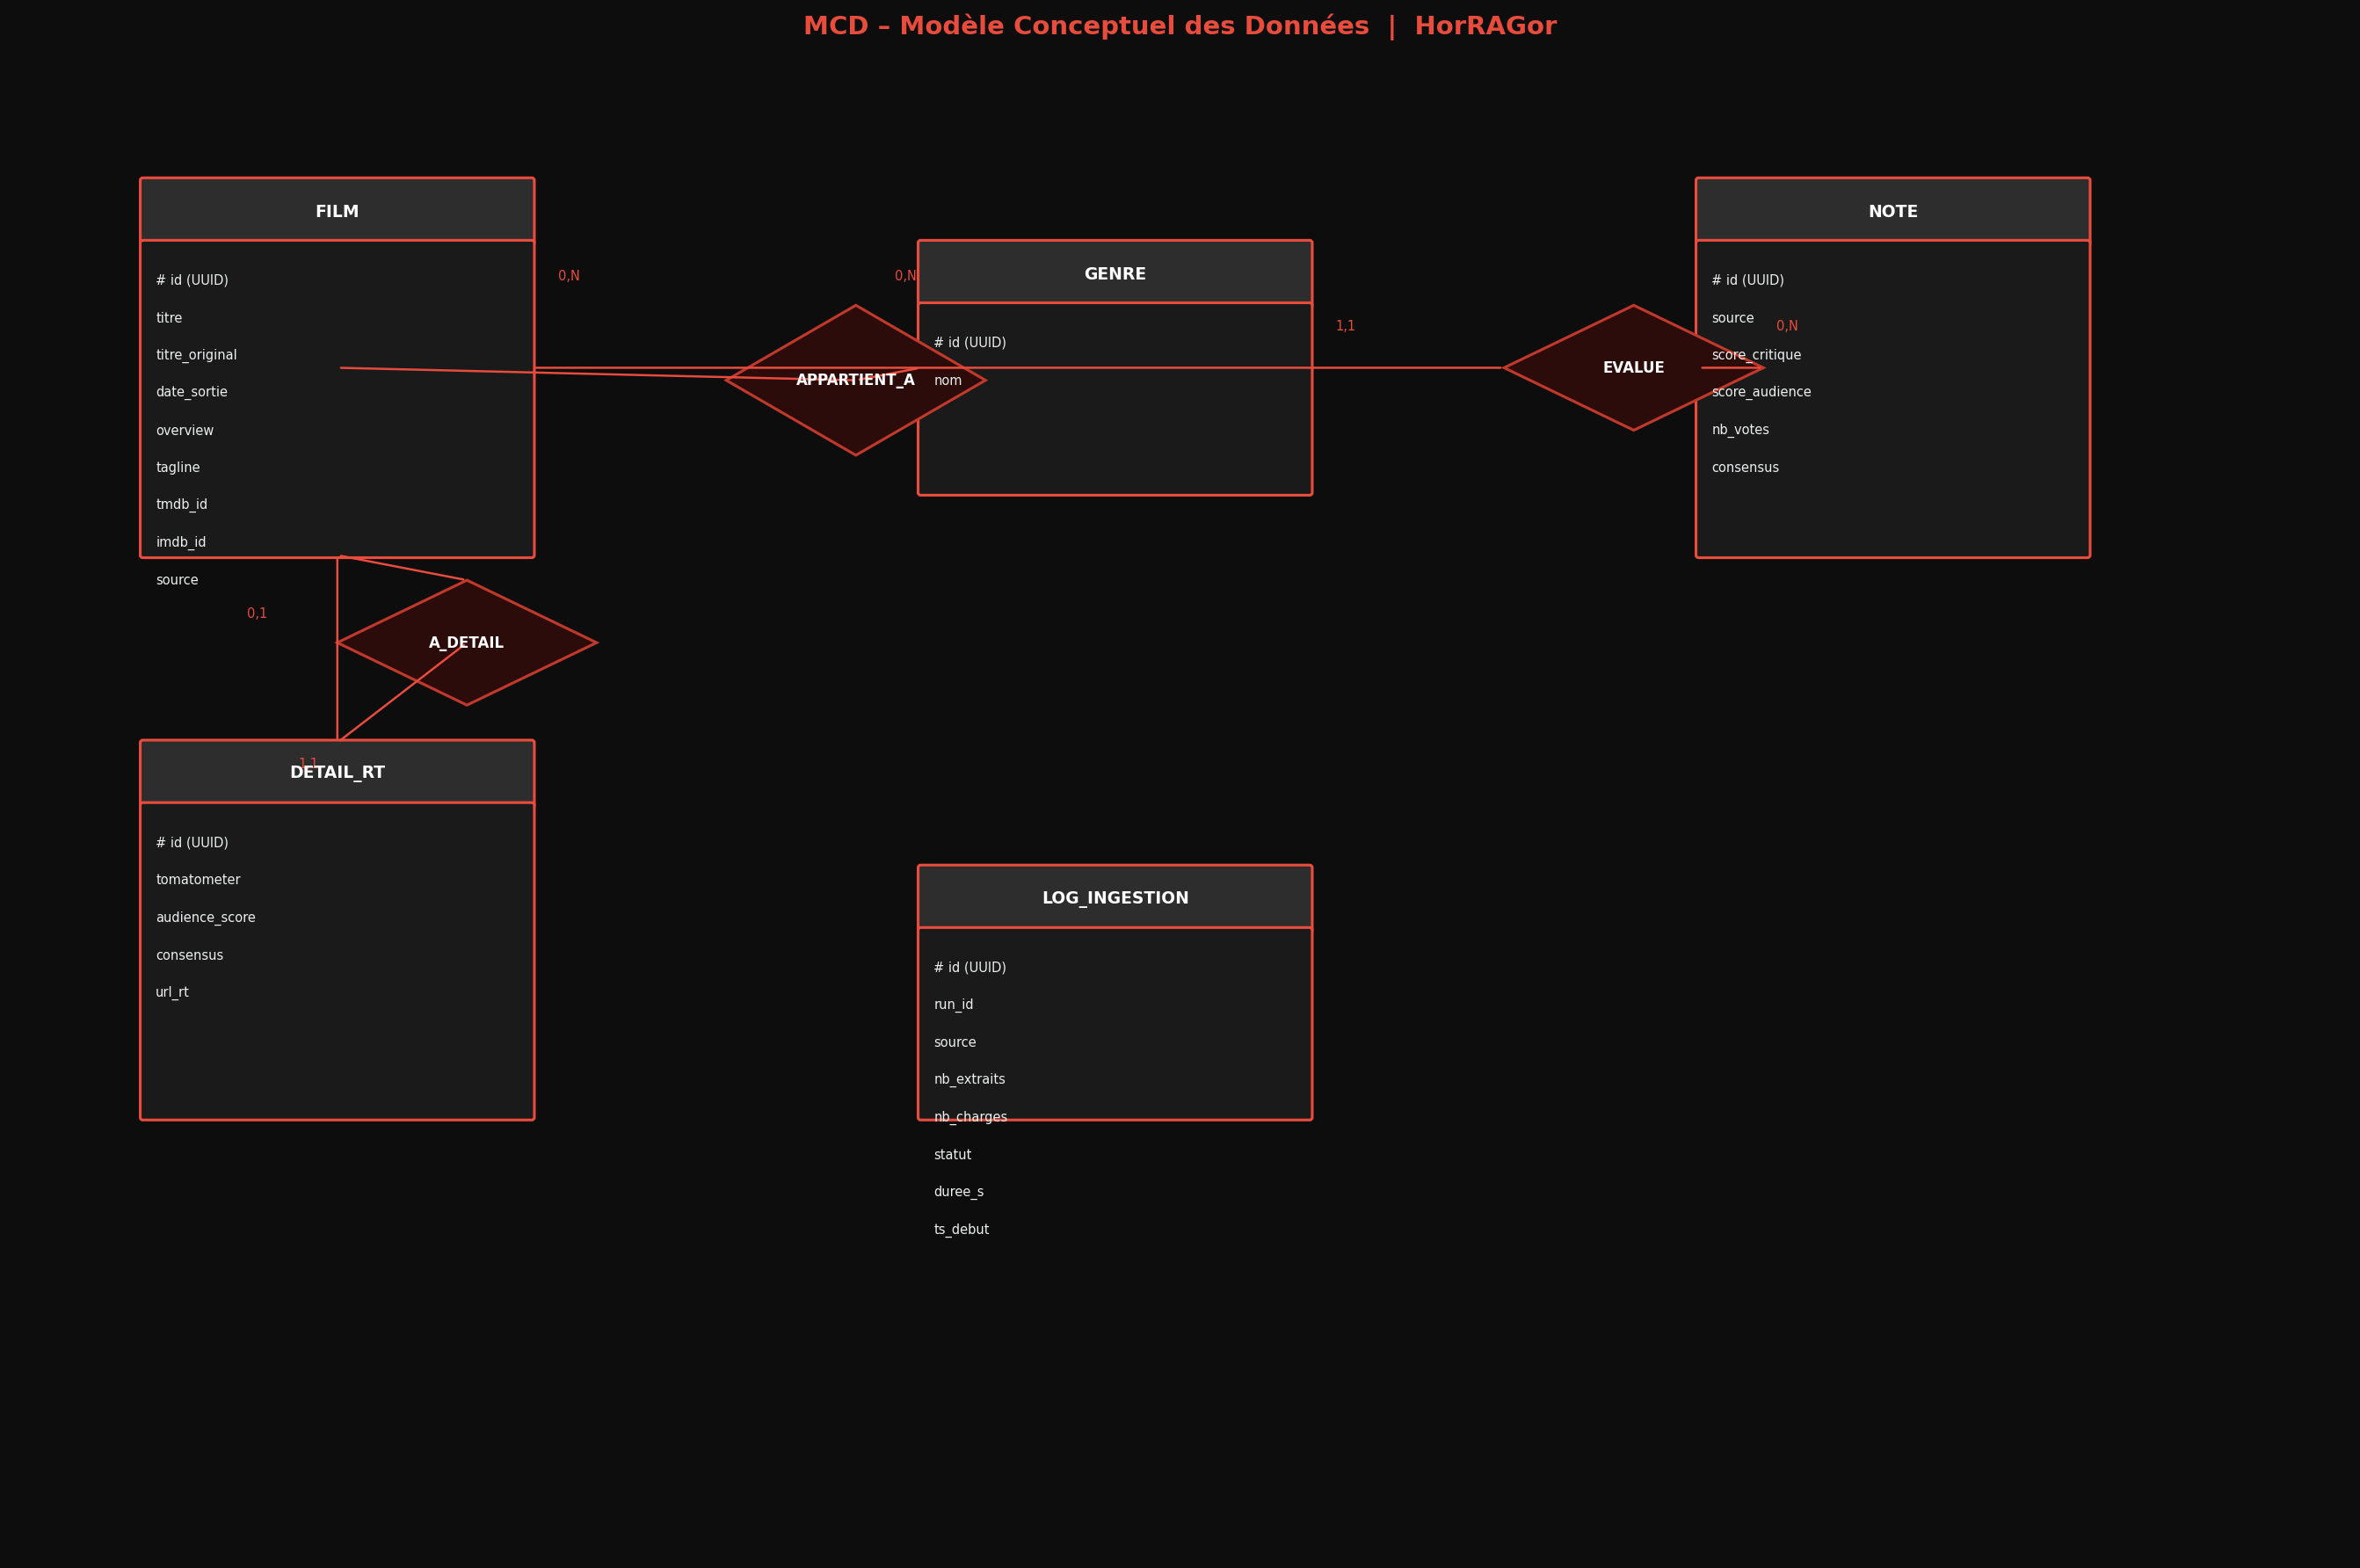

### MLD

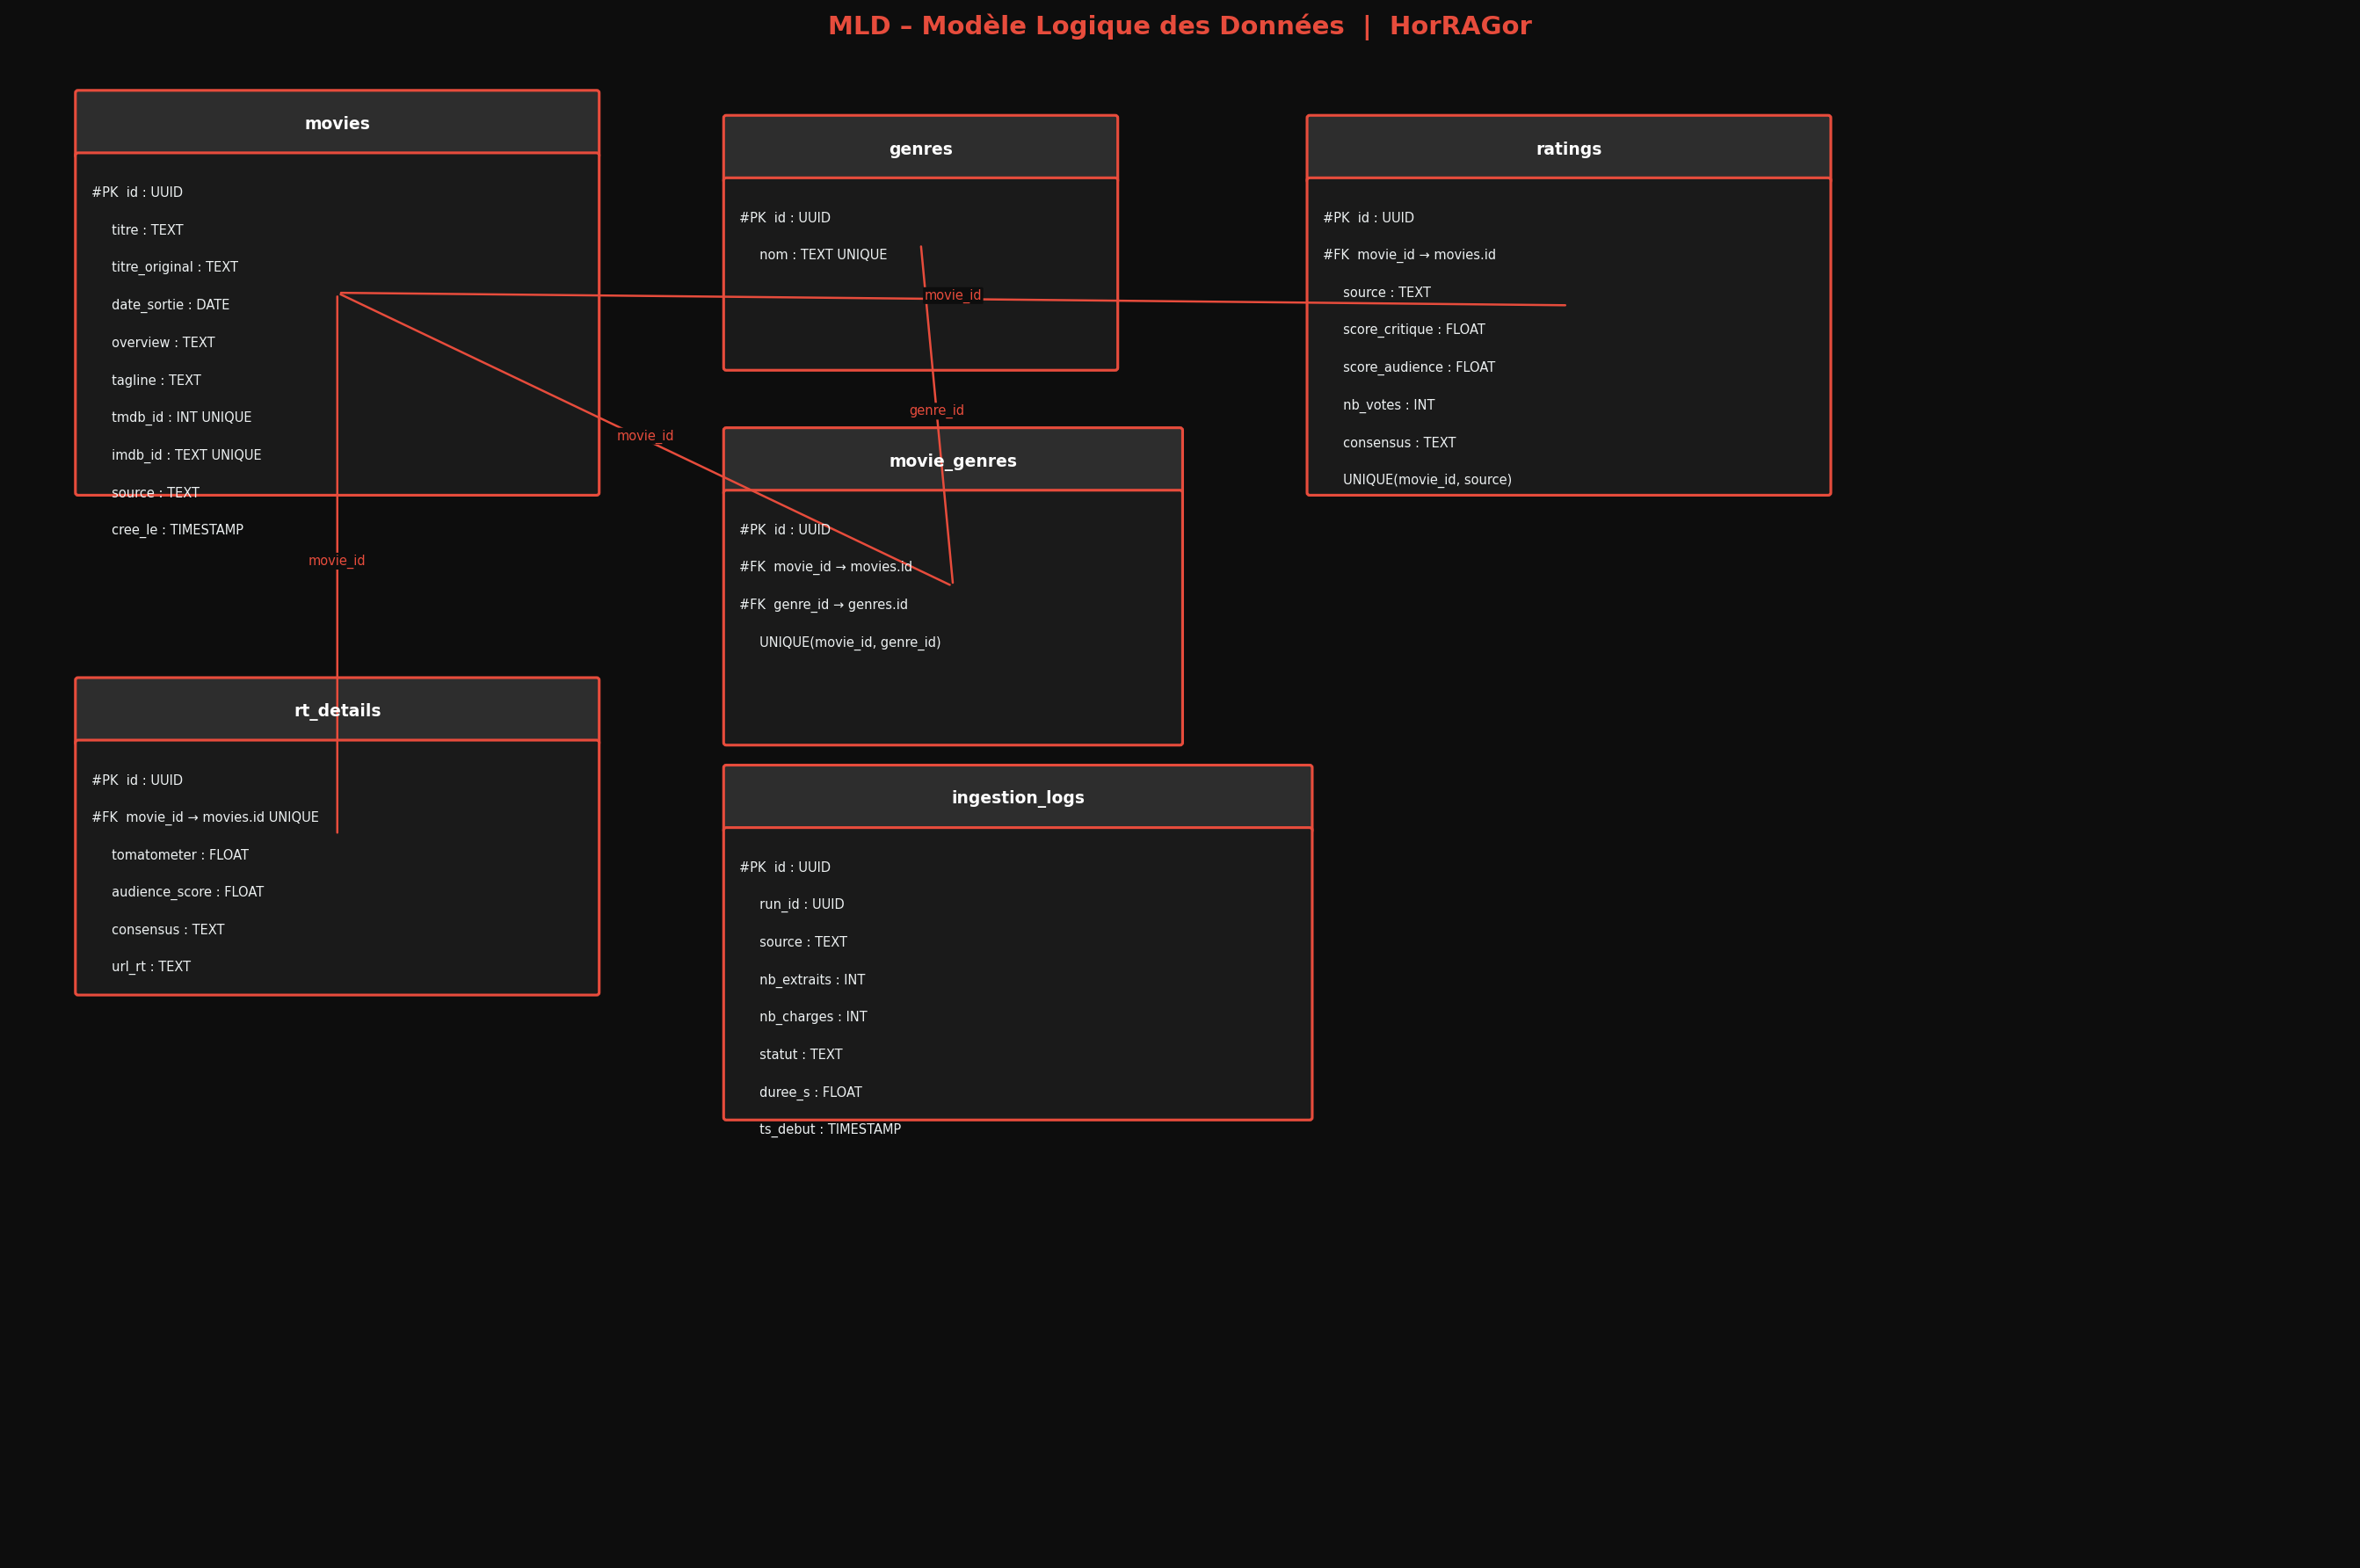

### MPD

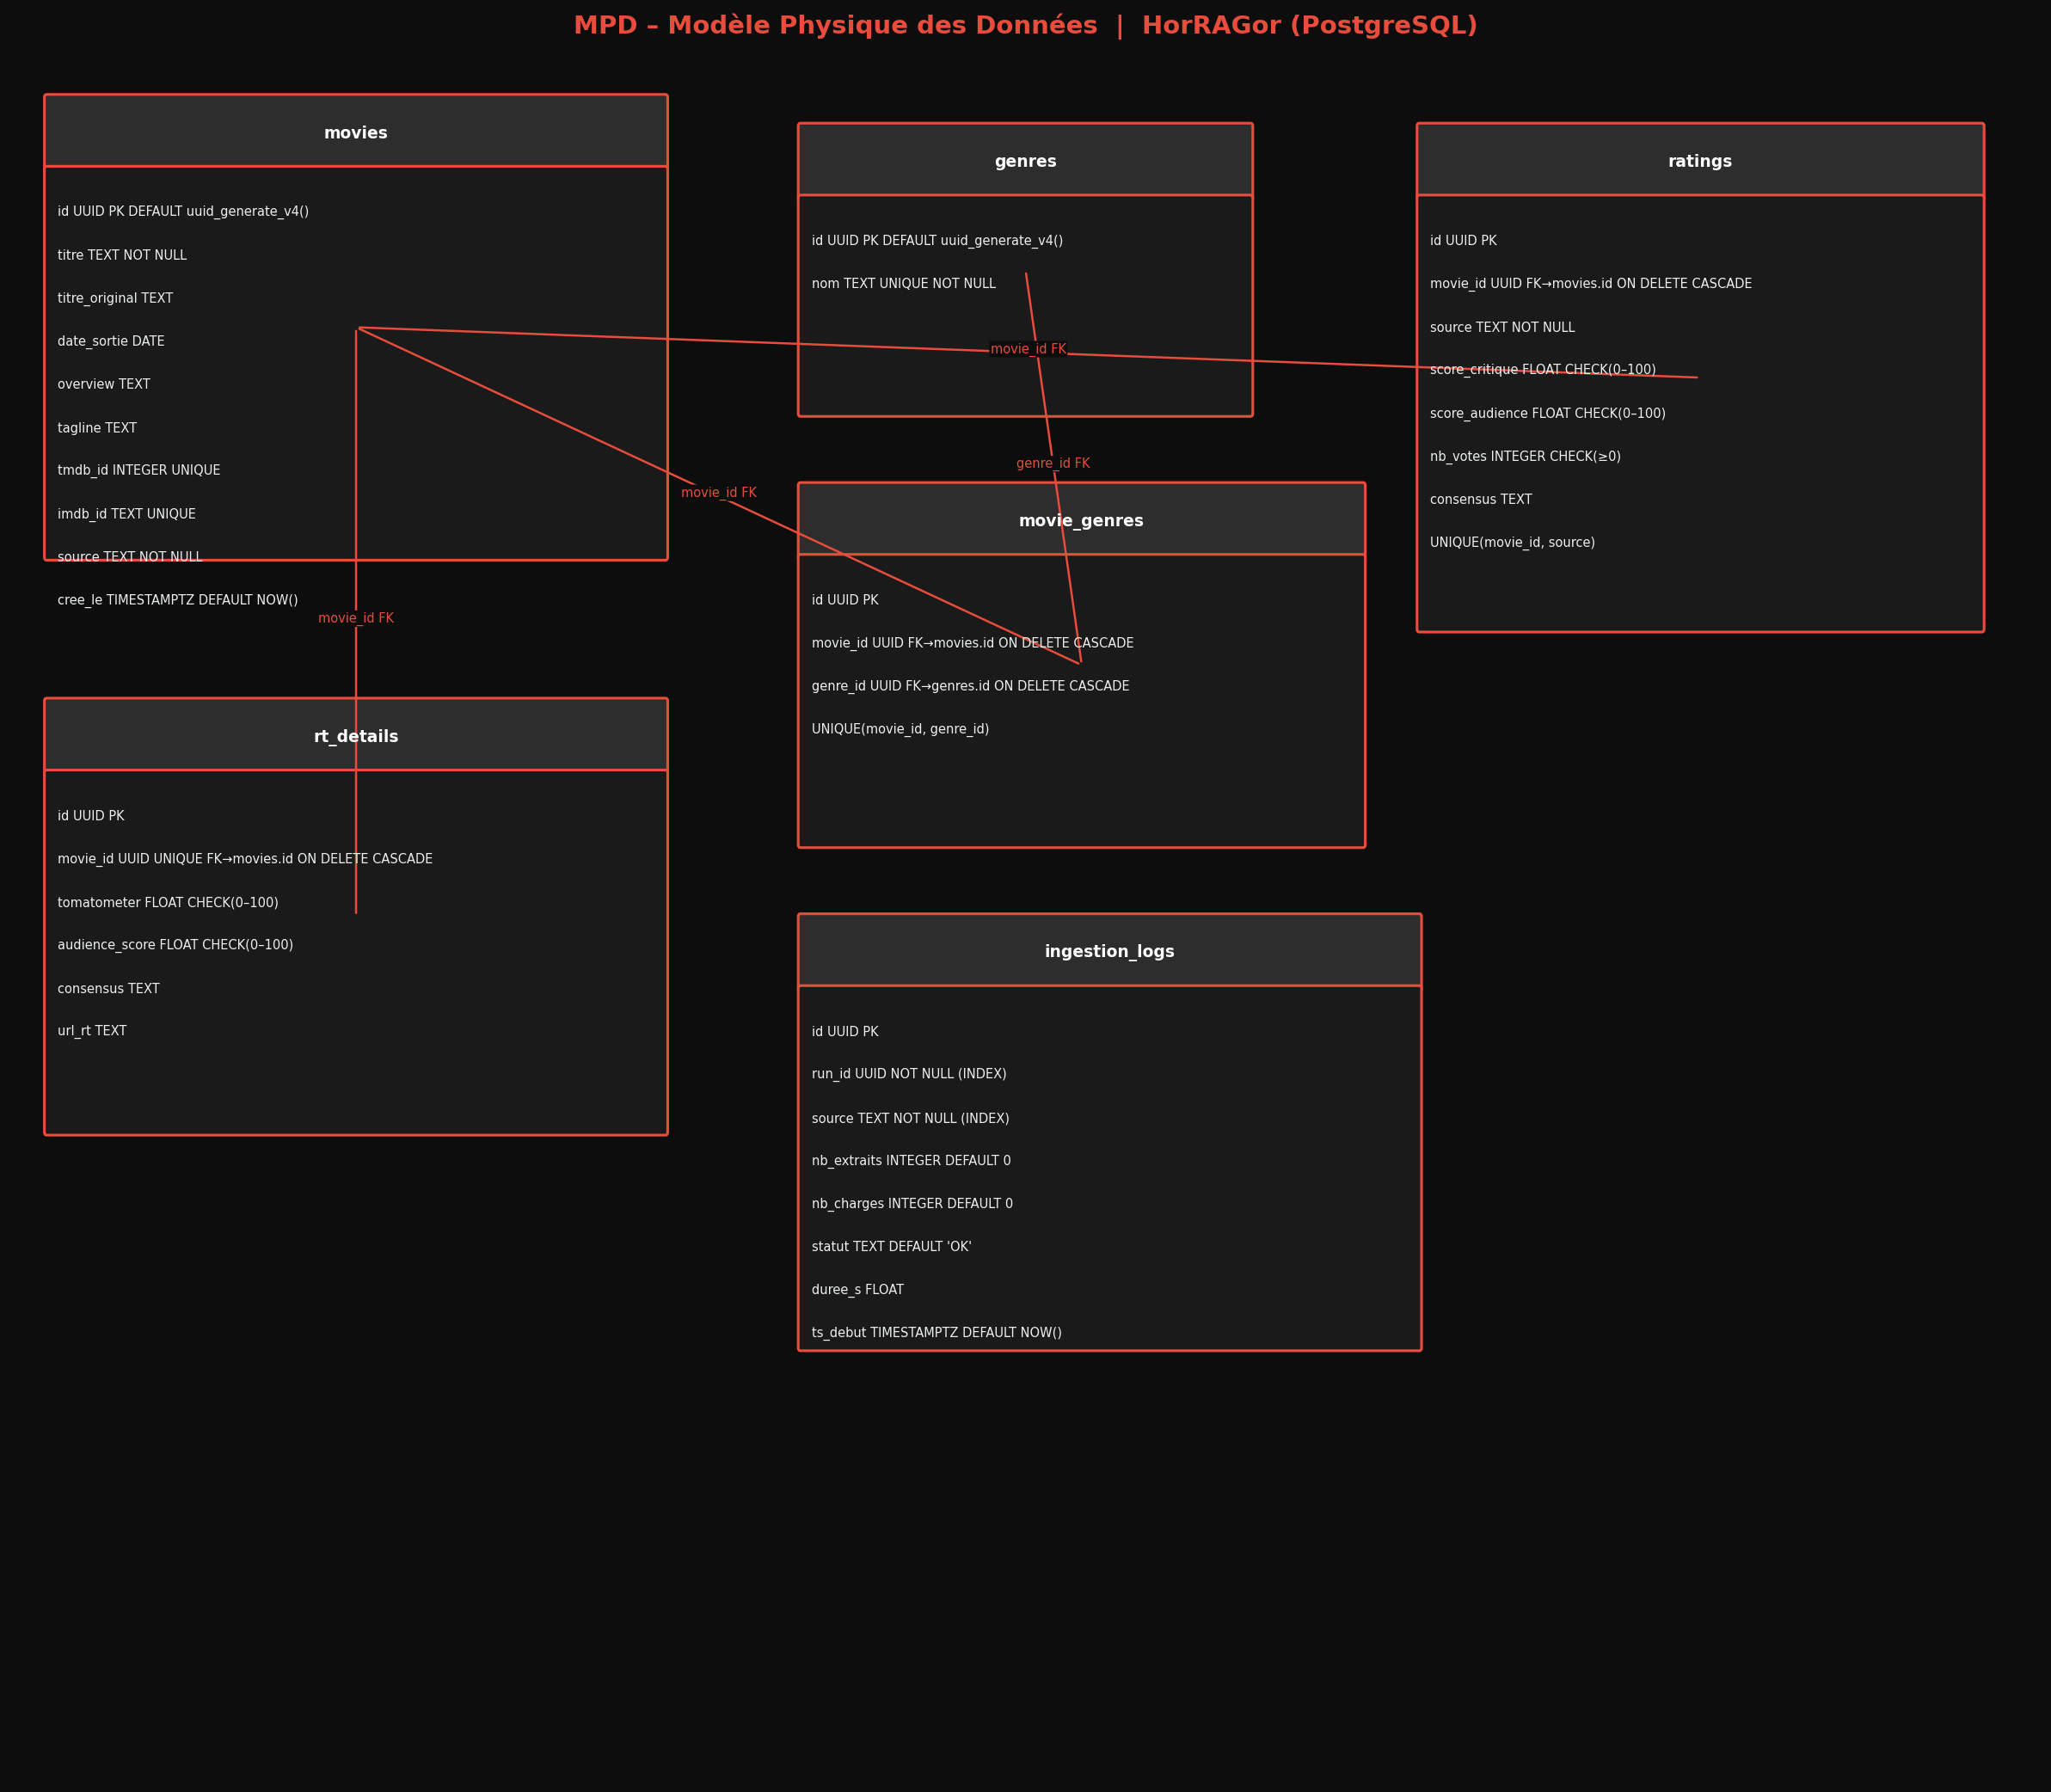

In [26]:
from IPython.display import Image, display as ipy_display, Markdown

merise_dir = PROJECT_ROOT / 'docs' / 'merise'

for diagram in ['MCD', 'MLD', 'MPD']:
    img_path = merise_dir / f'{diagram}.png'
    if img_path.exists():
        ipy_display(Markdown(f'### {diagram}'))
        ipy_display(Image(str(img_path), width=900))
    else:
        print(f'⚠️  {img_path} introuvable — lancez : python scripts/generate_merise.py')

## 9. Résumé & Commandes utiles

### Lancer le vrai pipeline

```bash
# Sans chargement Supabase (test local)
python -m src.pipeline --no-supabase

# Pipeline complet (nécessite .env avec clés API)
cp .env.example .env  # puis renseigner les valeurs
python -m src.pipeline
```

### Tests

```bash
pytest tests/ -v
```

### Construire la base IMDB

```bash
python scripts/build_imdb_db.py \
  --basics  data/raw/title.basics.tsv.gz \
  --ratings data/raw/title.ratings.tsv.gz \
  --output  data/raw/imdb_horror.db
```

### Régénérer les diagrammes Merise

```bash
python scripts/generate_merise.py
```